# 2.2

dependencies

In [63]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as opt

In [64]:
# Data Path initialization

# Determine script directory
base_path = Path.cwd()

# Paths for data and images
data_path = base_path / 'Data' / 'Datasheet.xlsx'
img_path = base_path.parent / 'Images'

# import data from path
Data = pd.read_excel(data_path, sheet_name='Bolzmannkonst', engine='openpyxl')

In [65]:
U40 =  np.array([[x, y] for x, y in zip(Data['U (T=40 C)'].tolist(), Data['Error U (T=40 C)'].tolist())])
U40 = U40[~np.isnan(U40).all(axis=1)]
I40 = np.array([[x, y] for x, y in zip(Data['I (T=40 C)'].tolist(), Data['Error I (T=40 C)'].tolist())])
I40 = I40[~np.isnan(I40).all(axis=1)]

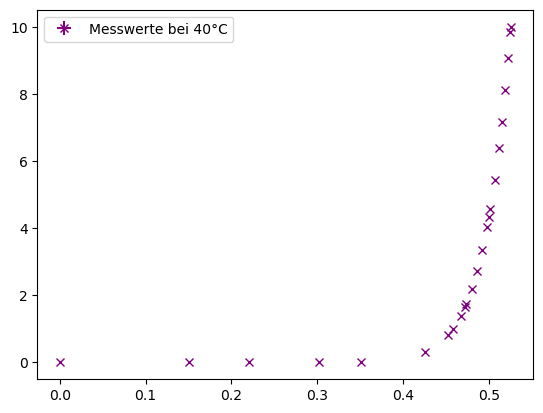

In [66]:
plt.errorbar(U40[:,0], I40[:,0], xerr=U40[:,1], yerr=I40[:,1], fmt='x', color='purple', label='Messwerte bei 40°C')
plt.legend()
plt.show()

40°C: a = 35.59660 ± 0.16412, b = -16.34072 ± 0.07856


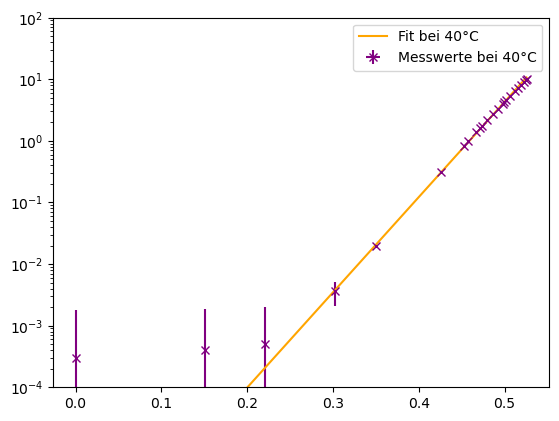

In [84]:
def lin(x,a,b):
    return a*x + b

lim = 0.3

mask = U40[:,0] >= lim

params40, cov40 = opt.curve_fit(lin, U40[mask,0], np.log(I40[mask,0]))
print("40°C: a = %.5f ± %.5f, b = %.5f ± %.5f" % (params40[0], np.sqrt(cov40[0,0]), params40[1], np.sqrt(cov40[1,1])))


plt.errorbar(U40[:,0], I40[:,0], xerr=U40[:,1], yerr=I40[:,1], fmt='x', color='purple', label='Messwerte bei 40°C')
plt.plot(U40[:,0], np.exp(lin(U40[:,0], *params40)), color='orange', label='Fit bei 40°C')
plt.yscale('log') 
plt.legend()
plt.ylim(1e-4, 1e2)
# plt.xlim(0.3, 0.55)
plt.show()


In [86]:
e = 1.602176634e-19  # elementary charge in coulombs
a = params40[0]
k = 1/a * e/(313.15)
print(k)

1.4373068800551707e-23
